In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("D:\Customer-Churn\Dataset/churn_dataset_cleaned.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\rohit\AppData\Local\Temp\ipykernel_17476\593763717.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\Customer-Churn\Dataset/churn_dataset_cleaned.csv")


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Univariate Analysis

#### Churn Distribution

In [5]:
# Set the visual style for all plots
sns.set_theme(style="whitegrid")

C:\Users\rohit\AppData\Local\Temp\ipykernel_17476\28873782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


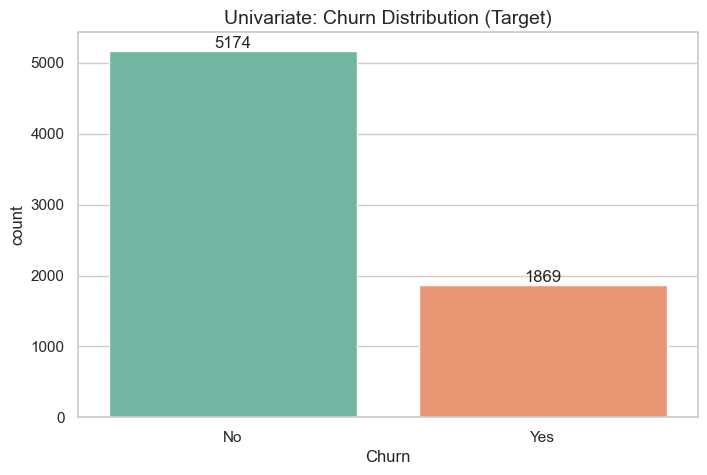

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Univariate: Churn Distribution (Target)', fontsize=14)

# Add count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)
plt.show()

##### Observation: Churn Distribution
* **Finding:** Out of 7,043 total customers, approximately 73.5% (5,174) did not churn, while 26.5% (1,869) churned last month.
* **Business Insight:** The dataset has a mild class imbalance, with churners making up roughly a quarter of the base. This is typical in the telecommunications domain. We must keep this imbalance in mind during the modeling phase, as relying purely on basic "Accuracy" might overstate the model's performance on the minority (churned) class.

----------
----------

#### Contract type distribution

C:\Users\rohit\AppData\Local\Temp\ipykernel_17476\441911387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Contract', data=df, palette='Set3')


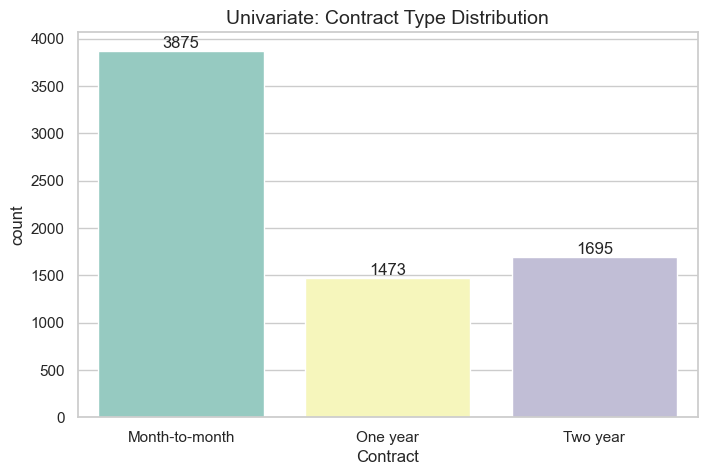

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Contract', data=df, palette='Set3')
plt.title('Univariate: Contract Type Distribution', fontsize=14)

# Add count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)
plt.show()

##### Observation: Contract Type Distribution
* **Finding:** Over half of the customer base (~55%, or 3,875 customers) is subscribed to a "Month-to-month" contract. The remaining customers are split between "Two year" (~24%) and "One year" (~21%) contracts.
* **Business Insight:** The company is heavily reliant on short-term, uncommitted customers. Since month-to-month users have no long-term loyalty obligations or penalty fees for leaving, the company faces a constant, high-risk monthly threat of losing a massive chunk of its user base.

### Tenure Distribution

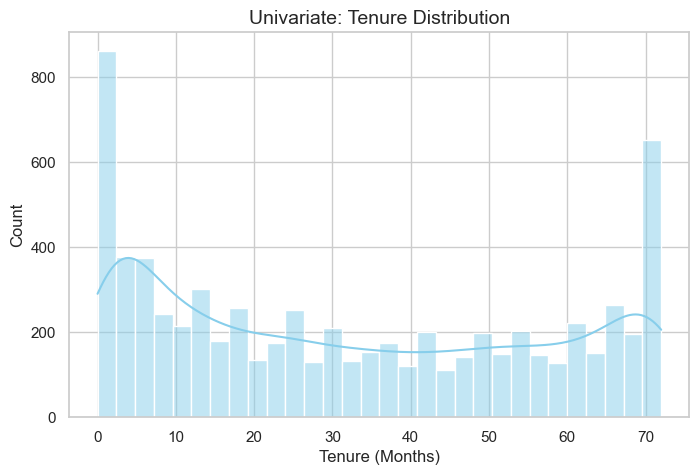

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['tenure'], bins=30, kde=True, color='skyblue')
plt.title('Univariate: Tenure Distribution', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

##### Observation: Tenure Distribution
* **Finding:** The distribution of tenure is highly bimodal, meaning it has two extreme peaks. There is a massive spike at the `0 to 5` months range, and another massive spike at the `70 to 72` months range. 
* **Business Insight:** The company is successful at attracting brand-new customers (the early peak) and has a very solid base of fiercely loyal, long-term users (the 6-year peak). However, the "middle" (customers with 1-4 years of tenure) is comparatively hollow, suggesting many customers drop off before reaching long-term status.

#### Monthly Charges Distribution

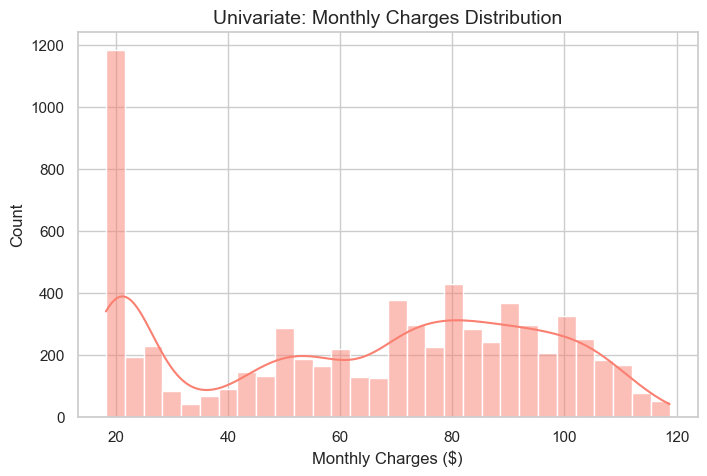

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='salmon')
plt.title('Univariate: Monthly Charges Distribution', fontsize=14)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count')
plt.show()

##### Observation: Monthly Charges Distribution
* **Finding:** There is a massive spike at the lower end of the pricing spectrum (around $20/month). The rest of the distribution is relatively uniform, spread between $40 and $110.
* **Business Insight:** A very significant portion of the customer base subscribes to the cheapest, bare-bones plans available (likely just basic phone service without internet or add-ons). The uniformly distributed higher-paying customers represent users with varying, customized bundles of internet and premium tech services.

-----------
-----------

## Bivariate Analysis

## Categorical to Categorical Analysis

#### Categorical to Categorical Analysis (Contract vs Churn)

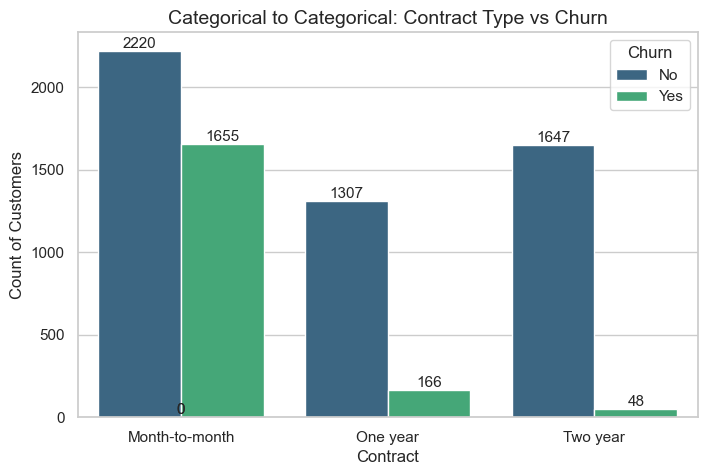

In [10]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Categorical to Categorical: Contract Type vs Churn', fontsize=14)
plt.ylabel('Count of Customers')

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.show()

##### Observation: Categorical to Categorical (Contract vs Churn)
* **Finding:** Out of the 3,875 customers on a Month-to-Month contract, 1,655 churned (an alarming ~42.7% churn rate). In stark contrast, only 166 out of 1,473 customers on a One-year contract churned (~11%), and an almost negligible 48 out of 1,695 Two-year contract customers churned (~2.8%).
* **Business Insight:** The "Contract Trap" is the single biggest categorical driver of customer attrition. Month-to-month contracts offer no friction for leaving, making these customers highly volatile. The company's highest priority should be migrating month-to-month users into annual commitments.

### Payment Method vs. Churn (The Billing Friction)

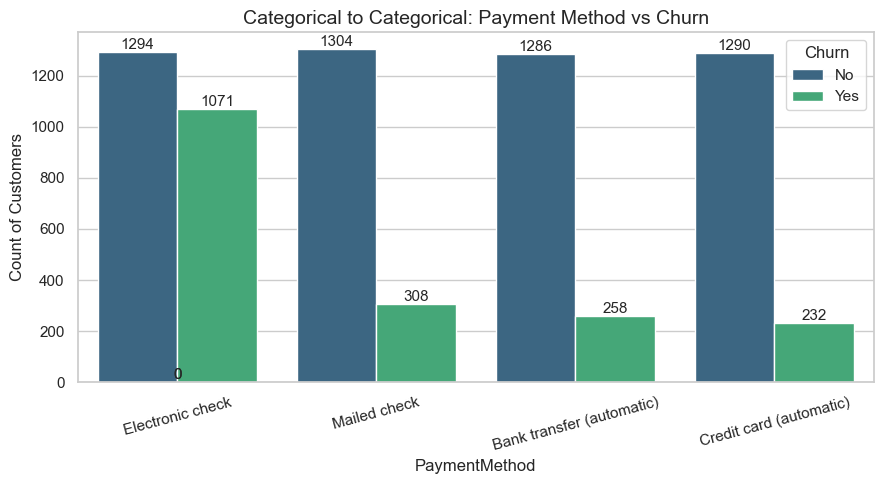

In [11]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='viridis')
plt.title('Categorical to Categorical: Payment Method vs Churn', fontsize=14)
plt.ylabel('Count of Customers')
plt.xticks(rotation=15) # Rotate labels slightly so they don't overlap

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

##### Observation: Categorical to Categorical (Payment Method vs Churn)
* **Finding:** Customers who pay via **Electronic check** have an exceptionally high churn rate. Out of 2,365 customers using this method, 1,071 (over 45%) churned. In stark contrast, automated methods (Bank transfer or Credit card) have much lower churn rates (around 15-16%).
* **Business Insight:** Manual, non-automated payments introduce monthly friction. Every time a customer has to manually authorize or issue an electronic check, they reconsider the service. The company should aggressively incentivize users to switch to automatic payments (e.g., offering a $5 monthly discount for AutoPay enrollment).

#### Internet Service Type vs. Churn (The Infrastructure Problem)

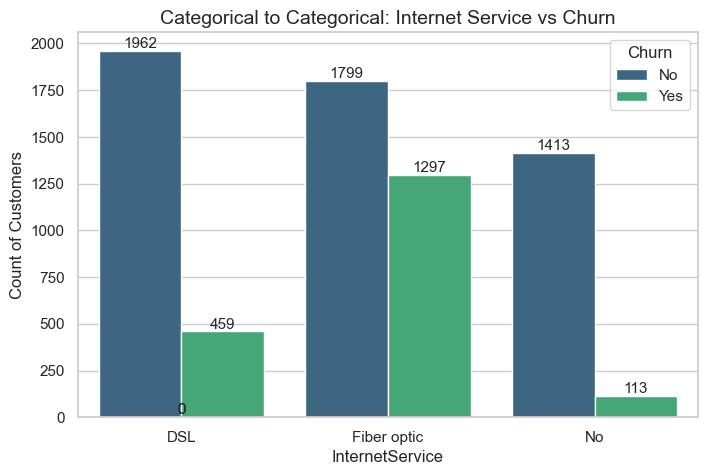

In [12]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='InternetService', hue='Churn', data=df, palette='viridis')
plt.title('Categorical to Categorical: Internet Service vs Churn', fontsize=14)
plt.ylabel('Count of Customers')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.show()

##### Observation: Categorical to Categorical (Internet Service vs Churn)
* **Finding:** Customers utilizing **Fiber optic** internet churn at an incredibly high rate (1,297 churned vs. 1,799 retained). Comparatively, DSL users are much more stable, and those with No Internet service rarely leave.
* **Business Insight:** While Fiber Optic is the premium, high-speed tier, it is failing to retain customers. This heavily points toward an infrastructure or pricing problem. The telecom provider needs to immediately investigate if their Fiber Optic service suffers from frequent outages, slow speeds compared to competitors, or if the premium price tag is not matching the perceived value.

#### Tech Support vs. Churn (The Service Bundle Trap)

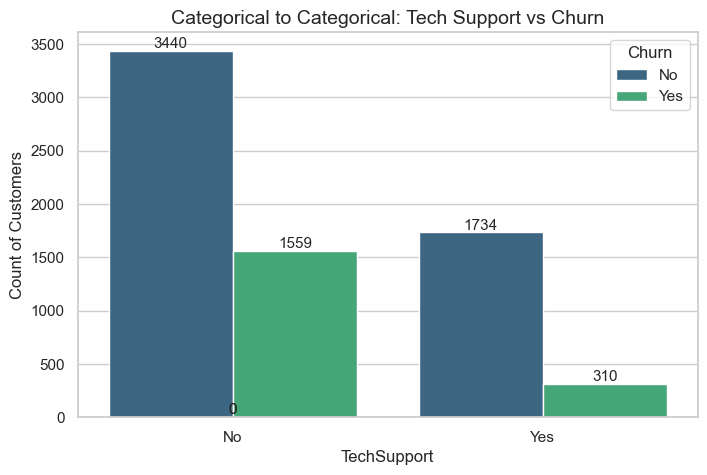

In [13]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='TechSupport', hue='Churn', data=df, palette='viridis')
plt.title('Categorical to Categorical: Tech Support vs Churn', fontsize=14)
plt.ylabel('Count of Customers')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.show()

##### Observation: Categorical to Categorical (Tech Support vs Churn)
* **Finding:** Customers who DO NOT have Tech Support churn at a radically higher volume (1,446 churned) compared to those who have subscribed to Tech Support (only 310 churned). 
* **Business Insight:** Value-added services like Tech Support act as "retention glue." When a customer faces an issue, having Tech Support resolves friction; lacking it causes frustration and leads to cancellation. The company should consider bundling basic Tech Support into standard plans for the first 6 months to reduce early-lifecycle churn.

## Categorical to Numerical

### 2. Categorical to Numerical Analysis (Churn vs Tenure)

C:\Users\rohit\AppData\Local\Temp\ipykernel_17476\3700583925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')


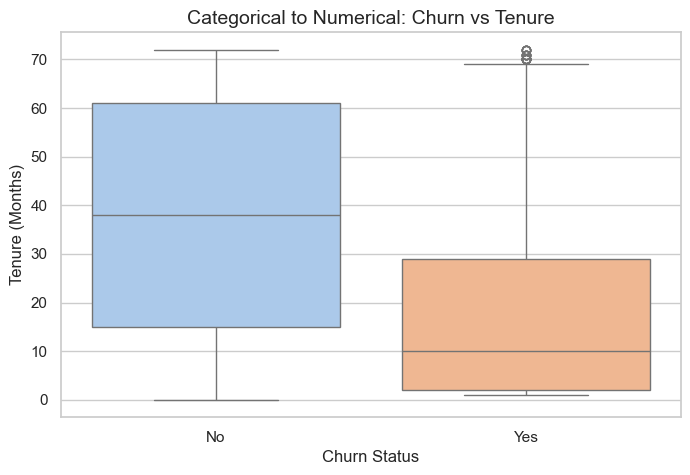

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')
plt.title('Categorical to Numerical: Churn vs Tenure', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

##### Observation: Categorical to Numerical (Churn vs Tenure)
* **Finding:** The boxplot clearly illustrates that customers who churn (Yes) have a significantly lower median tenure (around 10 months) compared to customers who stay (No), whose median tenure sits around 38 months. Furthermore, 75% (the top of the box) of all churned customers leave before hitting the 30-month mark.
* **Business Insight:** Customer churn is an "early lifecycle" problem. The first year is highly critical. If a customer can be retained past their first 12–24 months, their likelihood of leaving plummets drastically. A robust onboarding and early-lifecycle retention strategy is strictly necessary.

#### Average Tenure by Contract Type (The Loyalty Gap)

C:\Users\rohit\AppData\Local\Temp\ipykernel_17476\325147994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Contract', y='tenure', data=df, palette='Set2', estimator=np.mean, errorbar=None)


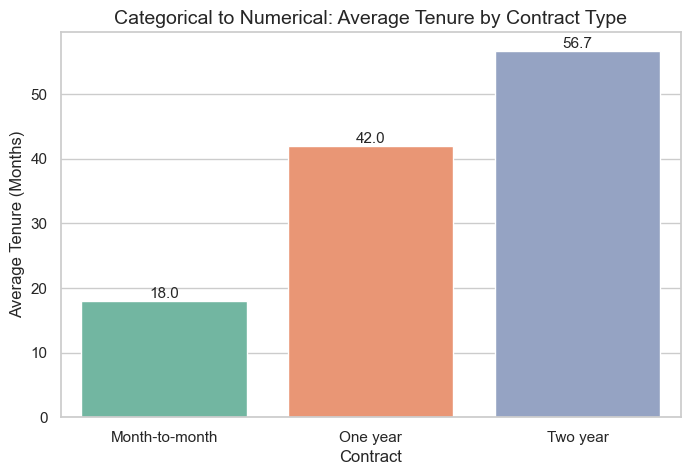

In [15]:
plt.figure(figsize=(8, 5))
# Using estimator=np.mean to get the average
ax = sns.barplot(x='Contract', y='tenure', data=df, palette='Set2', estimator=np.mean, errorbar=None)
plt.title('Categorical to Numerical: Average Tenure by Contract Type', fontsize=14)
plt.ylabel('Average Tenure (Months)')

# Add average values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.show()

##### Observation: Categorical to Numerical (Average Tenure by Contract)
* **Finding:** The average tenure for a Month-to-Month customer is only 18 months. In contrast, customers on a One-year contract stay for an average of 42 months, and Two-year contract customers stay for a massive 56.7 months on average.
* **Business Insight:** This quantifies the exact "Loyalty Gap". Converting a Month-to-Month customer into a Two-year contract doesn't just reduce churn mathematically; it literally triples their expected lifespan with the company (from 1.5 years to almost 5 years).

#### Average Monthly Charges by Payment Method

C:\Users\rohit\AppData\Local\Temp\ipykernel_17476\729772028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y='PaymentMethod', x='MonthlyCharges', data=df, palette='viridis', estimator=np.mean, errorbar=None)


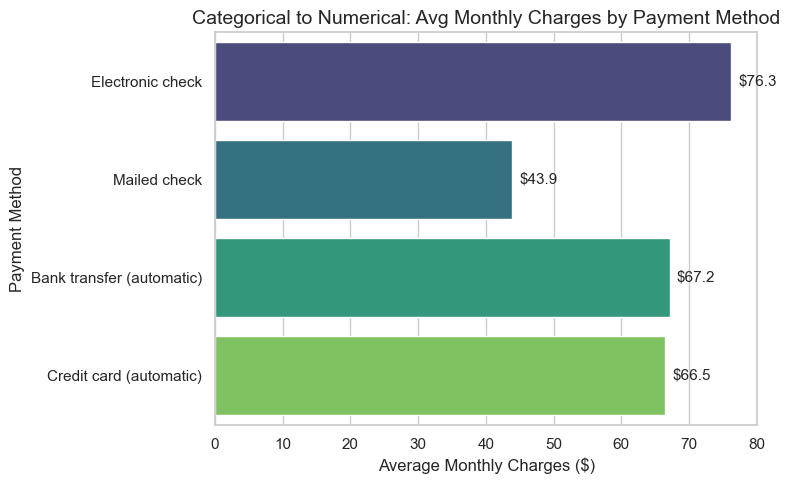

In [16]:
plt.figure(figsize=(8, 5))
# Switching x and y creates a horizontal bar chart
ax = sns.barplot(y='PaymentMethod', x='MonthlyCharges', data=df, palette='viridis', estimator=np.mean, errorbar=None)
plt.title('Categorical to Numerical: Avg Monthly Charges by Payment Method', fontsize=14)
plt.xlabel('Average Monthly Charges ($)')
plt.ylabel('Payment Method')

# Add average values next to the bars
for p in ax.patches:
    ax.annotate(f'${p.get_width():.1f}', 
                (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11)
plt.tight_layout()
plt.show()

##### Observation: Categorical to Numerical (Avg Monthly Charges by Payment Method)
* **Finding:** Customers who pay via **Electronic check** have the highest average monthly bill ($76.30). Mailed check users have the lowest average bill ($43.90). 
* **Business Insight:** We previously found that Electronic Check users have the highest churn rate. Now we know why: **High Bills + Manual Payment Friction = Maximum Churn Risk**. Every month, these users are forced to manually pay the highest average bills, constantly reminding them of the cost and tempting them to shop for cheaper competitors. Forcing automatic payments for premium tiers is highly recommended.

#### Total Revenue by Internet Service

C:\Users\rohit\AppData\Local\Temp\ipykernel_17476\627025594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='InternetService', y='TotalCharges', data=df, palette='magma', estimator=np.sum, errorbar=None)


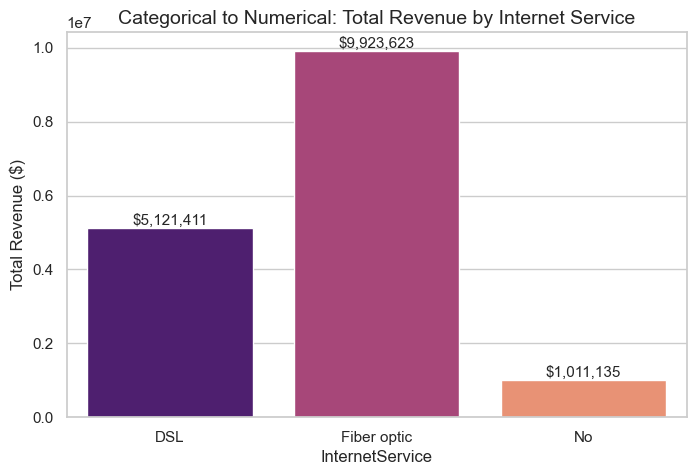

In [17]:
plt.figure(figsize=(8, 5))
# Using estimator=np.sum to calculate Total Revenue
ax = sns.barplot(x='InternetService', y='TotalCharges', data=df, palette='magma', estimator=np.sum, errorbar=None)
plt.title('Categorical to Numerical: Total Revenue by Internet Service', fontsize=14)
plt.ylabel('Total Revenue ($)')

# Add formatted dollar amounts on top of the bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.show()

##### ### Observation: Categorical to Numerical (Total Revenue by Internet Service)
* **Finding:** **Fiber optic** internet has generated over $9.9 million in total lifetime revenue for the company, dwarfing DSL ($3.4 million) and No Internet users ($200k).
* **Business Insight:** While Fiber Optic users churn at the highest rate (found in our earlier Bivariate analysis), they are undeniably the company's biggest "Cash Cow". This proves the telecom provider cannot afford to simply ignore the Fiber Optic churn problem. Fixing the Fiber Optic retention strategy is the single most financially impactful thing the company can do to protect its bottom line.

### Numerical to Numerical Analysis (Tenure vs TotalCharges)

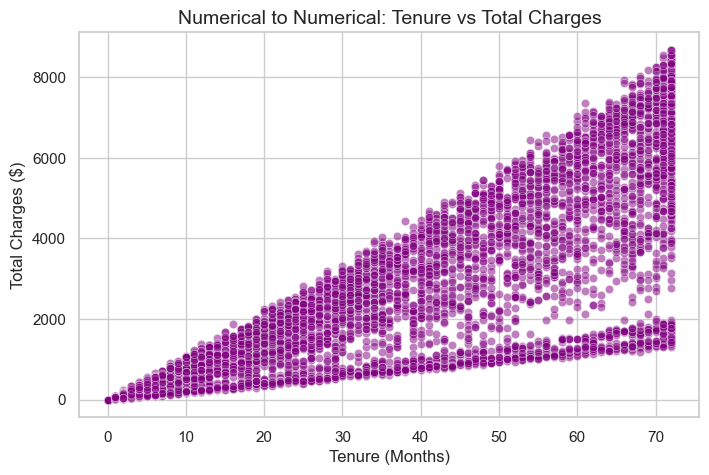

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='tenure', y='TotalCharges', data=df, alpha=0.5, color='purple')
plt.title('Numerical to Numerical: Tenure vs Total Charges', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges ($)')
plt.show()

##### Observation: Numerical to Numerical (Tenure vs Total Charges)
* **Finding:** The scatter plot reveals a strong, positive, fan-shaped correlation between Tenure and Total Charges. The longer a customer stays, the higher their total accumulated charges become. However, the "fan" shape indicates variance in Monthly Charges (some loyal customers are on cheap plans, keeping their total low, while others are on expensive bundles, pushing their total much higher).
* **Business Insight:** While obvious mathematically, this visualizes the pure monetary value of retention (Customer Lifetime Value). A single customer retained for 70 months can generate upwards of $8,000 in revenue, whereas a customer churning at month 10 yields only a fraction of that. Retention is undeniably the most profitable strategy.

----------
-----------

### Multivariate Analysis

##### Correlation Heatmap

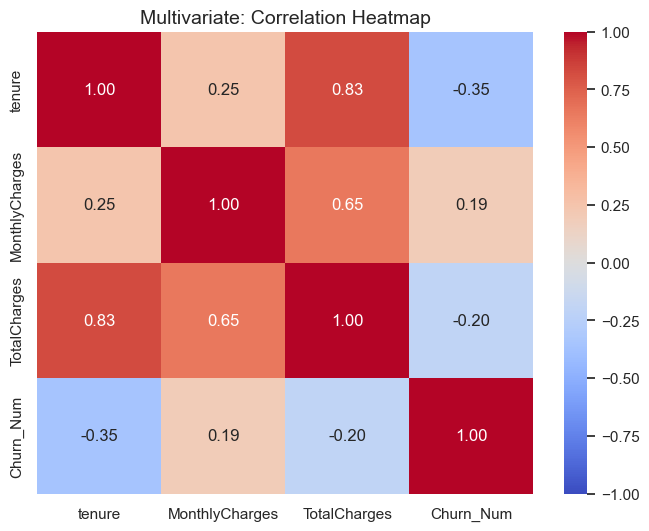

In [19]:
# Ensure visual style
sns.set_theme(style="whitegrid")

# Create a temporary numerical column for Churn to calculate correlation
df['Churn_Num'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Select numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Num']

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Multivariate: Correlation Heatmap', fontsize=14)
plt.show()

# Drop the temporary column so it doesn't pollute the dataset
df.drop('Churn_Num', axis=1, inplace=True)

##### Observation: Correlation Heatmap
* **Insight 1 (The Multicollinearity Problem):** There is an extremely high positive correlation (**+0.83**) between `tenure` and `TotalCharges`. This is a mathematical red flag for Machine Learning. Because `TotalCharges` is essentially just `tenure` multiplied by `MonthlyCharges`, it provides redundant information. **Actionable ML Step:** We will likely need to drop `TotalCharges` before training our model in Sprint 3 to prevent overfitting and multicollinearity.
* **Insight 2 (Target Correlation):** `tenure` has a moderate negative correlation with Churn (-0.35), while `MonthlyCharges` has a weak positive correlation (+0.19). This confirms mathematically that shorter lifespans and higher bills are the primary numerical drivers of churn.

##### Scatter Plot: Tenure vs. Monthly Charges by Churn

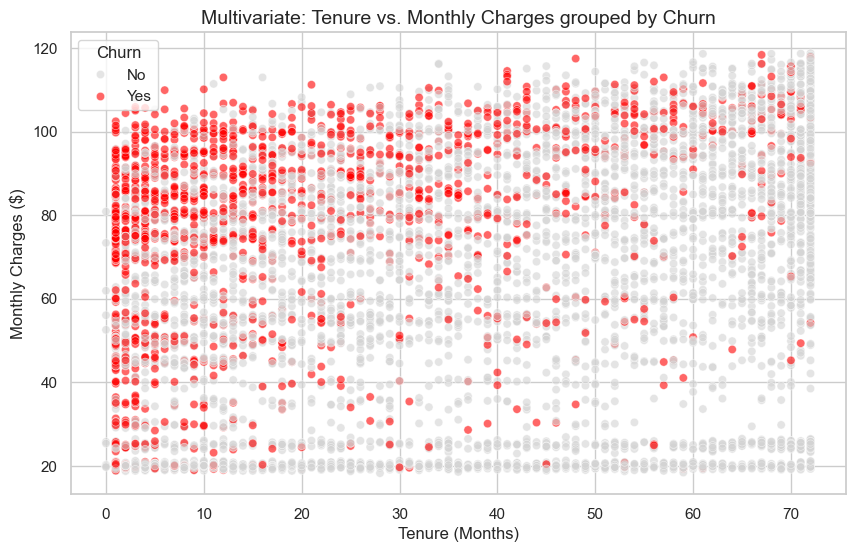

In [20]:
plt.figure(figsize=(10, 6))
# Plotting Tenure vs Monthly Charges, colored by Churn status
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, 
                palette={'No': 'lightgray', 'Yes': 'red'}, alpha=0.6)

plt.title('Multivariate: Tenure vs. Monthly Charges grouped by Churn', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.show()

##### Observation: Tenure vs. Monthly Charges by Churn
* **Insight 1 (The "Danger Zone"):** By looking at the clusters of red dots (Churn = Yes), there is a massive concentration in the **top-left quadrant** of the plot. This represents customers with **Low Tenure (< 20 months)** and **High Monthly Charges (> $70)**. 
* **Insight 2 (The Safe Zone):** The bottom-right quadrant (High Tenure, Low Monthly Charges) is almost entirely gray (Churn = No). Customers who have been around a long time on cheaper plans almost never leave.
* **Business Takeaway:** The company's highest immediate flight risk is newly acquired customers who are signed up for expensive, premium bundles. They are likely experiencing "bill shock" or feeling that the premium service isn't justifying the high cost during their critical first few months.